# Capstone Project: Data Science

In [1]:
#! pip install selenium 
#! pip install beautifulsoup4

In [47]:
## importing necessary libraries
import bs4 
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests
from selenium import webdriver
import csv
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# for webscrapping I use Books to Scrape website to scrape the books data.


#  PHASE 1: WEB SCRAPING (Python)


In [49]:
url="https://books.toscrape.com/catalogue/page-1.html"
response= requests.get(url)
soup= BeautifulSoup(response.text,"html.parser")


In [50]:
soup


<!DOCTYPE html>

<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-us"> <!--<![endif]-->
<head>
<title>
    All products | Books to Scrape - Sandbox
</title>
<meta content="text/html; charset=utf-8" http-equiv="content-type"/>
<meta content="24th Jun 2016 09:30" name="created"/>
<meta content="" name="description"/>
<meta content="width=device-width" name="viewport"/>
<meta content="NOARCHIVE,NOCACHE" name="robots"/>
<!-- Le HTML5 shim, for IE6-8 support of HTML elements -->
<!--[if lt IE 9]>
        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>
        <![endif]-->
<link href="../static/oscar/favicon.ico" rel="shortcut icon"/>
<link href="../static/oscar/css/styles.css" rel="stylesheet" type="text/css"/>
<link 

In [51]:
books = soup.find_all("article", class_="product_pod")
print("Books found:", len(books))

Books found: 20


In [52]:
book = books[0]

title = book.h3.a["title"]
price = book.find("p", class_="price_color").text
price = price.replace("Â£", "").replace("£", "")
price = float(price)
rating = book.p["class"][1]

print(title)
print(price)
print(rating)

A Light in the Attic
51.77
Three


In [53]:
# Rating mapping (text → number)
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}
## for scrapping the data of multiple pages we use FOR LOOP function.
all_books = []

for page in range(1, 51):
    print(f"Scraping page {page}...")

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    # because we need atleast 1000 records. 
    if len(books) == 0:
        break

    for book in books:
       
        title = book.h3.a["title"]

        # PRICE CLEANING
        price = book.find("p", class_="price_color").text
        price = price.replace("Â£", "").replace("£", "")
        price = float(price)

        # Convert to INR
        price_inr = round(price * 105, 2)

        # Rating conversion
        rating_text = book.p["class"][1]
        rating = rating_map[rating_text]

        # cleaned data
        all_books.append([title, price, price_inr, rating])




Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Scraping page 36...
Scraping page 37...
Scraping page 38...
Scraping page 39...
Scraping page 40...
Scraping page 41...
Scraping page 42...
Scraping page 43...
Scraping page 44...
Scraping page 45...
Scraping page 46...
Scraping page 47...
Scraping page 48...
Scraping page 49...
Scraping page 50...


In [55]:
## converting the scrape data into CSV file

with open("clean_books.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Title", "Price_GBP", "Price_INR", "Rating"])
    writer.writerows(all_books)

print("DONE Dataset saved as clean_books.csv")
print("Total records:", len(all_books))

DONE Dataset saved as clean_books.csv
Total records: 1000


# PHASE 2 : DATA CLEANING & PREPROCESSING

In [57]:
## • Handle missing values & duplicates 
## • Fix inconsistent formats (date, text, numbers) 
## • Create useful features (rating %, price band, category, etc.) 
## • Convert raw, messy data → structured analytics table 

## done these steps in EXCEL.

In [10]:
df=pd.read_excel(r"C:\Users\My\Documents\data science\Capstone_project\clean_books(new).xlsx")
df.head()

,Title,Price_GBP,Price_INR,Rating,Rating_%,Affordability Tier
0,A Light in the Attic,51.77,5435.85,3,0.6,Expensive
1,Tipping the Velvet,53.74,5642.70,1,0.2,Expensive
2,Soumission,50.10,5260.50,1,0.2,Expensive
3,Sharp Objects,47.82,5021.10,4,0.8,Expensive
4,Sapiens: A Brief History of Humankind,54.23,5694.15,5,1.0,Expensive


## PHASE 3 : EXPLORATORY DATA ANALYSIS (EDA)

In [58]:
##  Summary statistics (mean, median, spread) 


In [30]:
df[['Price_GBP', 'Price_INR','Rating_%']].median()

Price_GBP      35.98
Price_INR    3777.90
Rating_%     6000.00
dtype: float64

In [26]:
df[['Price_GBP','Price_INR', 'Rating_%']].mean()

Price_GBP      35.07035
Price_INR    3682.38675
Rating_%     5846.00000
dtype: float64

In [31]:
df[['Price_GBP','Price_INR','Rating_%']].std()

Price_GBP      14.446690
Price_INR    1516.902415
Rating_%     2869.933888
dtype: float64

In [34]:
Q1 = df[['Price_GBP','Price_INR','Rating_%']].quantile(0.25)
Q3 = df[['Price_GBP','Price_INR','Rating_%']].quantile(0.75)
IQR = Q3 - Q1

print(IQR)

Price_GBP      25.35
Price_INR    2661.75
Rating_%     4000.00
dtype: float64


In [59]:
# • Trend analysis (time, category, rating, price, etc.) 
# • Visualizations: 
# - Bar / Line / Scatter 
# - Boxplots (outliers) 
#- Heatmap (correlations) 


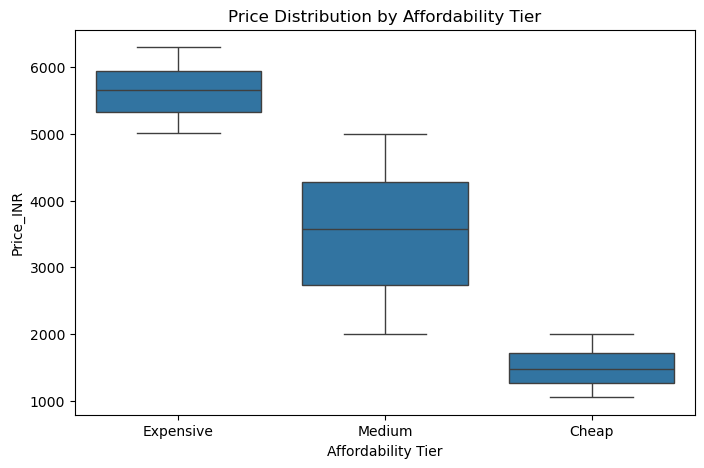

In [38]:
## Affordability Tier vs Price

plt.figure(figsize=(8,5))
sns.boxplot(x='Affordability Tier', y='Price_INR', data=df)
plt.title("Price Distribution by Affordability Tier")
plt.show()

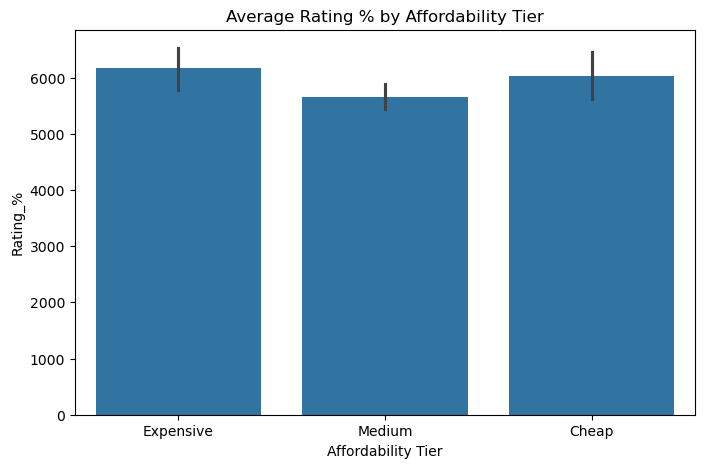

In [39]:
## Affordability Tier VS. Rating %

plt.figure(figsize=(8,5))
sns.barplot(x='Affordability Tier', y='Rating_%', data=df)
plt.title("Average Rating % by Affordability Tier")
plt.show()

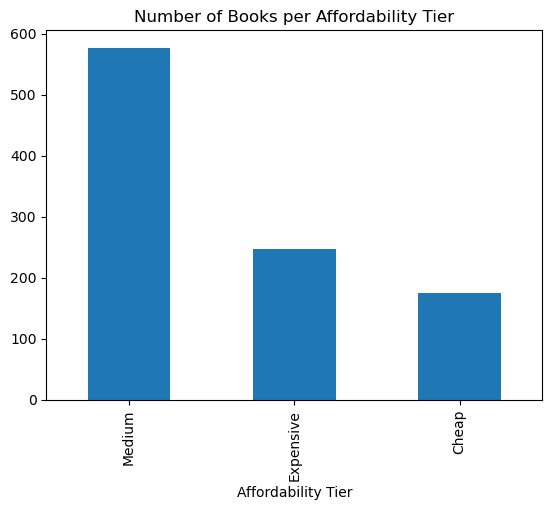

In [40]:
## Count of Books per Tier

df['Affordability Tier'].value_counts().plot(kind='bar')
plt.title("Number of Books per Affordability Tier")
plt.show()

In [41]:
df.groupby('Affordability Tier')[['Price_INR', 'Rating_%']].mean()

,Price_INR,Rating_%
Affordability Tier,,
Cheap,1495.086000,6022.857143
Expensive,5638.144355,6169.354839
Medium,3505.176603,5653.379549


In [42]:
df.groupby('Affordability Tier')[['Price_INR', 'Rating_%']].agg(['mean', 'median', 'std'])

Price_INR                          Rating_%          \
                           mean   median         std         mean  median   
Affordability Tier                                                          
Cheap               1495.086000  1480.50  266.011762  6022.857143  6000.0   
Expensive           5638.144355  5659.50  363.422371  6169.354839  6000.0   
Medium              3505.176603  3566.85  883.677238  5653.379549  6000.0   

                                 
                            std  
Affordability Tier               
Cheap               2892.626945  
Expensive           2877.306923  
Medium              2848.816735

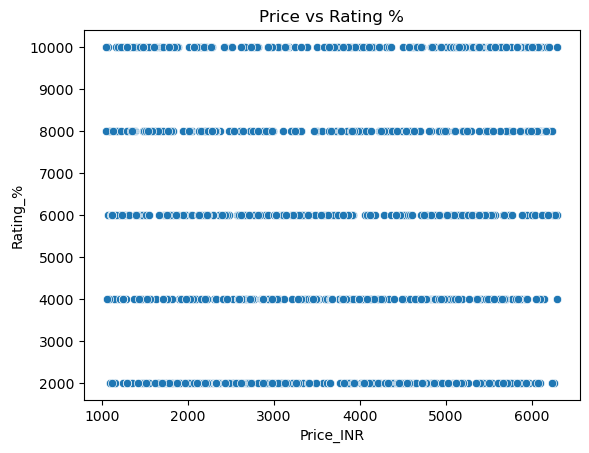

In [43]:


sns.scatterplot(x='Price_INR', y='Rating_%', data=df)
plt.title("Price vs Rating %")
plt.show()

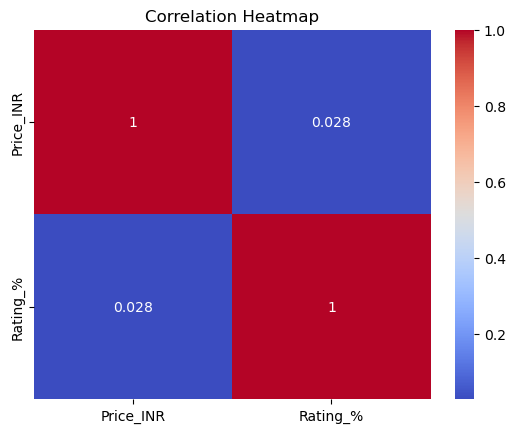

In [45]:
## heatmap for correalation between Price_INR and Rating_%

corr = df[['Price_INR', 'Rating_%']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [60]:
## • Identify trends, patterns & anomalies:

## As we can see through BOX plot of price distribution by Affordability Tier the 
## "medium" tier of affordability have higher value compare to other Tiers.
## and the rating of "Expensive" Affordability Tier is higher.
## through the heatmap we can say that there is no strong correlation between Price_INR and Rating_%. 
  